In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
from data_pipeline import load_and_prepare_data, load_single_channel
from feature_engineering import build_model_input
from algorithms import gpr
import plots, evaluate

In [41]:
X_train_loso, X_test_loso, y_train_loso, y_test_loso = load_and_prepare_data(data_folder="../data/04-03-24")

X_train: (1068, 66), y_train: (1068,)
X_test: (1130, 66), y_test: (1130,)
Train capacity range: 0.0 - 1.0 mAh
Test capacity range: 0.0 - 1.0 mAh


# Faster Model training

In [47]:
cap_model = gpr.train_capacity_gpr_fast(
    X_train_loso, y_train_loso,
    subset_size=300,
    top_k_freqs=None  
)


In [49]:
y_pred_mean, y_pred_std = gpr.predict_fast(cap_model, X_test_loso)

RMSE: 0.3040
R²: 0.1450
MSE: 0.0924
MAE: 0.1403
  Mean Prediction Uncertainty: 0.0621


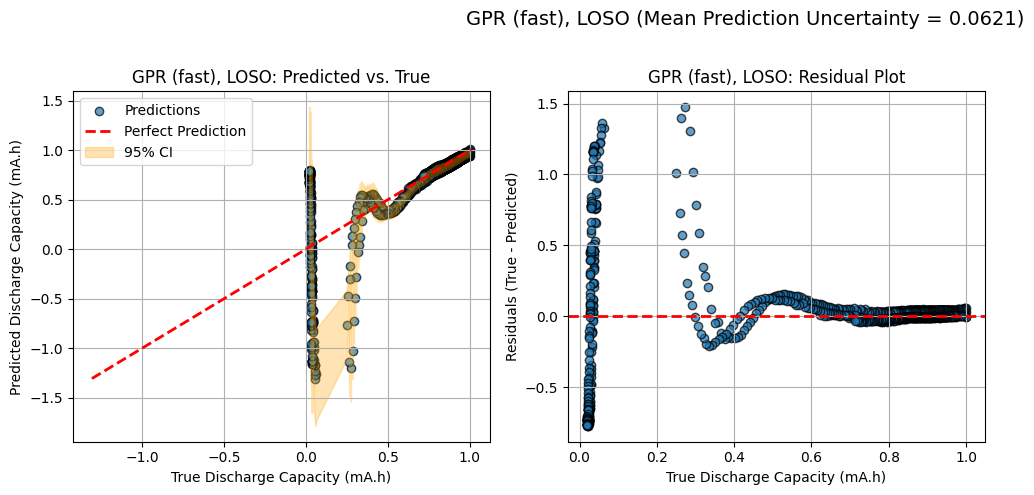

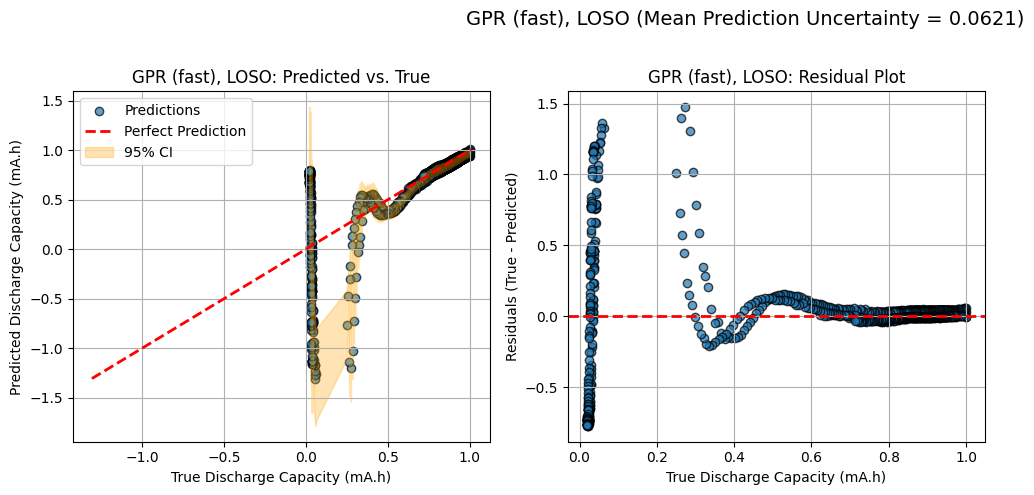

In [52]:
rmse, r2, mse, mae = evaluate.evaluate_model(y_test_loso, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
plots.model_predictions(y_test_loso, y_pred_mean, y_pred_std, title_prefix="GPR (fast), LOSO")

# Binning split

In [ ]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = load_and_prepare_data(data_folder="../data/04-03-24",method='bin_and_split')

X_train: (1727, 66), y_train: (1727,)
X_test: (471, 66), y_test: (471,)
Train capacity range: 0.0 - 1.0 mAh
Test capacity range: 0.0 - 1.0 mAh


In [ ]:
cap_model = gpr.train_capacity_gpr_fast(
    X_train_bin, y_train_bin,
    subset_size=300,
    top_k_freqs=None  
)

In [56]:
y_pred_mean, y_pred_std = gpr.predict_fast(cap_model, X_test_bin)

RMSE: 0.0478
R²: 0.9730
MSE: 0.0023
MAE: 0.0430
  Mean Prediction Uncertainty: 0.0087


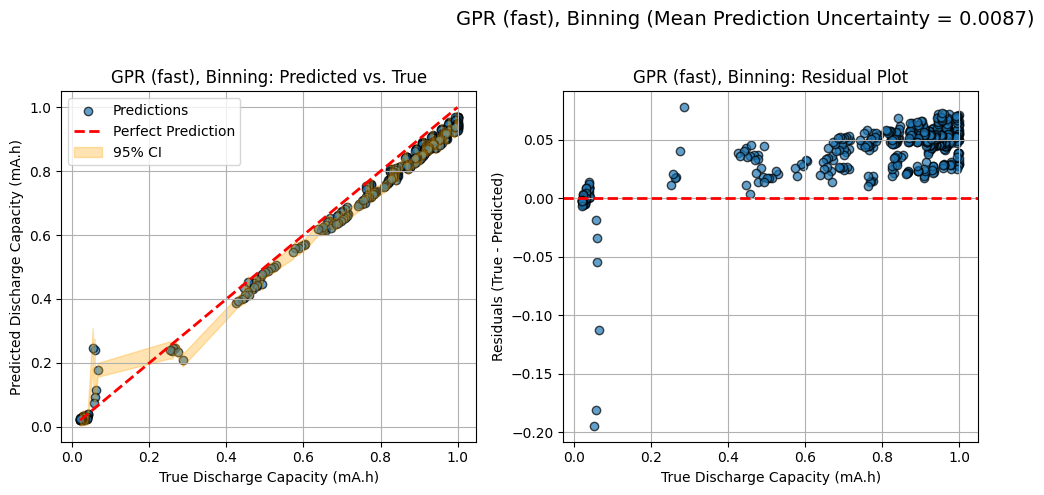

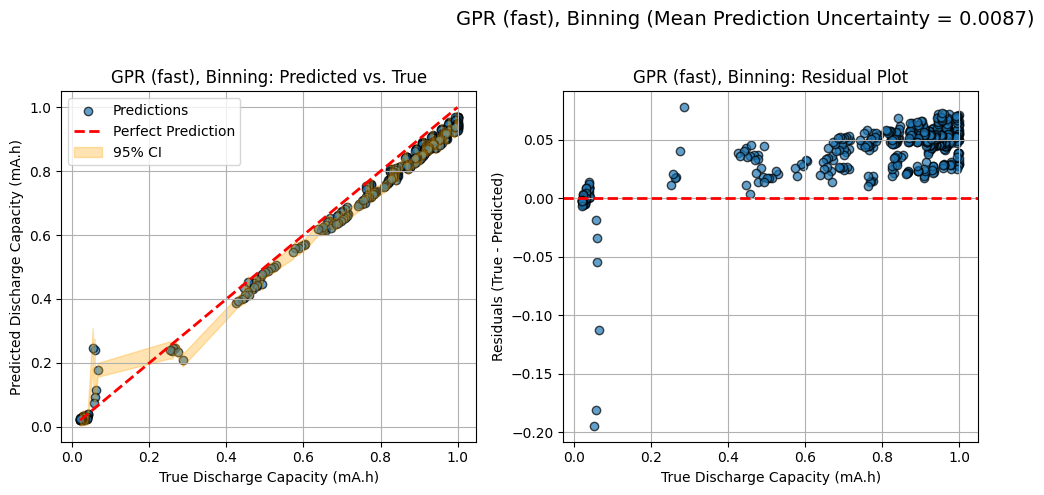

In [57]:
rmse, r2, mse, mae = evaluate.evaluate_model(y_test_bin, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
plots.model_predictions(y_test_bin, y_pred_mean, y_pred_std, title_prefix="GPR (fast), Binning")

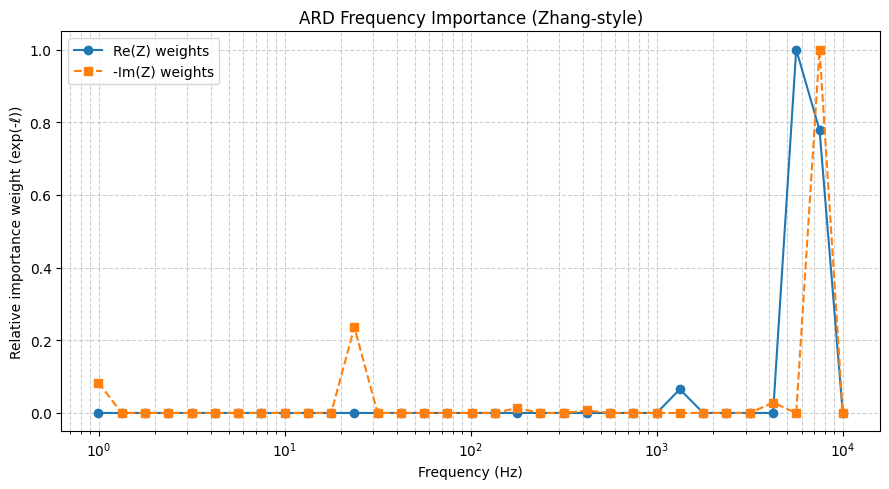

Top 5 most relevant frequencies (Hz): [7.50e+03 5.62e+03 2.37e+01 9.99e-01 1.33e+03]
Corresponding weights: [0.88907141 0.5        0.11808552 0.04172806 0.03258754]


In [ ]:
w = gpr.ard_frequency_weights(cap_model)       # shape (66,)
plots.gpr_weights(w)

In [ ]:
# Split into Re/Im and aggregate per frequency
n_freq = w.size // 2
w_re, w_im = w[:n_freq], w[n_freq:]
w_mean = (w_re + w_im) / 2

# Top frequencies
top = np.argsort(w_mean)[::-1][:10]
print("Top-10 freqs (index):", top)
print("Weights:", w_mean[top])

Top-10 freqs (index): [31 30 11  0 25 29 18 21  6 22]
Weights: [8.89071414e-01 5.00000000e-01 1.18085518e-01 4.17280640e-02
 3.25875386e-02 1.41743006e-02 6.83521554e-03 3.38562451e-03
 6.54502757e-07 1.57855609e-18]


# Fast Loso with Determined weights

In [2]:
def loso(train_channels, test_channels):
    train_channels_data = {}
    test_channels_data = {}
    for channel in train_channels: train_channels_data[channel] = load_single_channel("../data/04-03-24", channel)    
    for channel in test_channels: test_channels_data[channel] = load_single_channel("../data/04-03-24", channel)
    train_dfs = list(train_channels_data.values())
    test_dfs = list(test_channels_data.values())

    return pd.concat(train_dfs, ignore_index=True), pd.concat(test_dfs, ignore_index=True)


In [5]:
CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']
results = []

for test_cell in CHANNELS:
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])

    X_train, y_train = build_model_input(df_train)
    X_test,  y_test  = build_model_input(df_test)

    model = gpr.train_capacity_gpr_fast(X_train, y_train, subset_size=500)
    y_pred, y_std = gpr.predict_fast(model, X_test)

    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    results.append((test_cell, rmse, mae, r2))


In [6]:
results

[('A1',
  np.float64(0.033059093528765744),
  0.021215210317251335,
  0.9048775134544871),
 ('A2',
  np.float64(0.040102690564182496),
  0.03671958726847968,
  0.9055903688188802),
 ('A3',
  np.float64(0.04800253663504828),
  0.0388599656875871,
  0.695574349216532),
 ('A4',
  np.float64(0.11422712828182685),
  0.06280642699125828,
  0.6691884603316673),
 ('A5',
  np.float64(0.08771937235396607),
  0.06926335248456333,
  0.9467089150666883),
 ('A6',
  np.float64(0.00939030828241265),
  0.009211048998826013,
  0.8849035984290692),
 ('A7',
  np.float64(0.11544515847836954),
  0.08264512101347626,
  0.9041637076290333),
 ('A8',
  np.float64(0.008492188337659277),
  0.0062655974023528285,
  0.9804121384856345)]

In [8]:
import os, json

df = pd.DataFrame(results, columns=["cell", "rmse", "mae", "r2"]).sort_values("cell")

summary = pd.DataFrame({
    "cell": ["_mean_"],
    "rmse": [df["rmse"].mean()],
    "mae":  [df["mae"].mean()],
    "r2":   [df["r2"].mean()],
})
df_out = pd.concat([df, summary], ignore_index=True)

save_dir = os.path.join("../results", "gpr")
os.makedirs(save_dir, exist_ok=True)

csv_path  = os.path.join(save_dir, "gpr_8_fold_cv_results.csv")
json_path = os.path.join(save_dir, "gpr_8_fold_cv_results.json")

df_out.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(df.to_dict(orient="records"), f, indent=2)

print(f"Results saved to:\n  • {csv_path}\n  • {json_path}")
print("\n Fold-wise summary:\n", df_out)


Results saved to:
  • ../results/gpr/gpr_8_fold_cv_results.csv
  • ../results/gpr/gpr_8_fold_cv_results.json

 Fold-wise summary:
      cell      rmse       mae        r2
0      A1  0.033059  0.021215  0.904878
1      A2  0.040103  0.036720  0.905590
2      A3  0.048003  0.038860  0.695574
3      A4  0.114227  0.062806  0.669188
4      A5  0.087719  0.069263  0.946709
5      A6  0.009390  0.009211  0.884904
6      A7  0.115445  0.082645  0.904164
7      A8  0.008492  0.006266  0.980412
8  _mean_  0.057055  0.040873  0.861427


# Plot weights

In [9]:
import matplotlib.pyplot as plt

# --- where to save
save_dir = os.path.join("../results", "gpr")
os.makedirs(save_dir, exist_ok=True)

CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']

W_re, W_im = [], []
freqs_hz = [
    0.999, 1.33, 1.78, 2.37, 3.16, 4.22, 5.62, 7.5, 
    10.0, 13.3, 17.8, 23.7, 31.6, 42.2, 56.2, 75.0, 
    102.0, 135.0, 178.0, 237.0, 316.0, 422.0, 564.0, 750.0, 
    1000.0, 1330.0, 1780.0, 2370.0, 3160.0, 4220.0, 5620.0, 7500.0, 
    10000.0
]

In [10]:
for test_cell in CHANNELS:
    # 1) LOSO split
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])

    X_train, y_train = build_model_input(df_train)

    # 3) train fast capacity GP (Zhang-style ARD)
    model = gpr.train_capacity_gpr_fast(
        X_train, y_train,
        subset_size=500,     # you can tune
        top_k_freqs=None     # keep all freqs here to get full ARD profile
    )

    # 4) ARD weights (per feature), then split into Re/Im and average per frequency
    w = gpr.ard_frequency_weights(model)     # length 2*Nfreq
    n_freq = w.size // 2
    w_re = w[:n_freq]
    w_im = w[n_freq:]

    # optional: normalize per fold so curves are comparable (comment out if not desired)
    w_re = w_re / (np.max(w_re) + 1e-12)
    w_im = w_im / (np.max(w_im) + 1e-12)

    W_re.append(w_re)
    W_im.append(w_im)

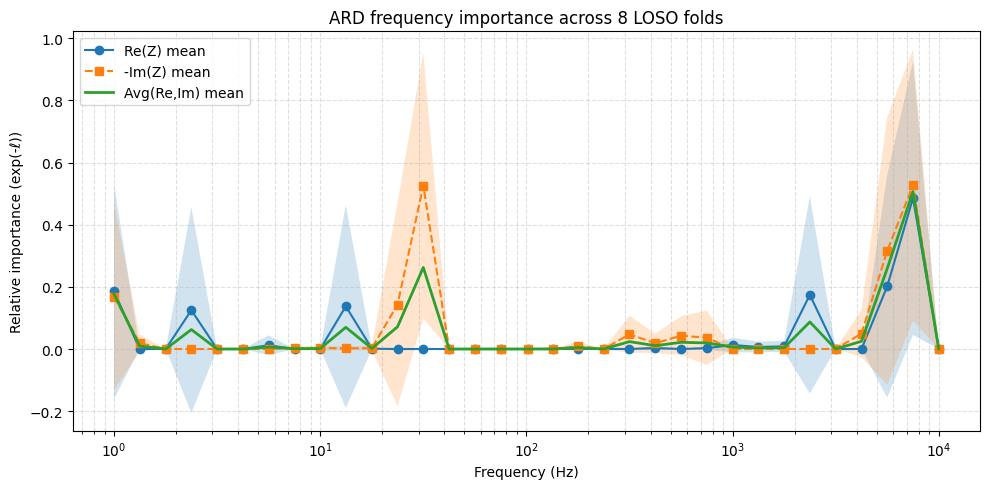

Saved ARD summary to:
- ../results/gpr/ard_weights_across_folds.csv
- ../results/gpr/ard_weights_across_folds.png


In [ ]:
W_re = np.vstack(W_re)   # [8, n_freq]
W_im = np.vstack(W_im)

# mean/std across folds
re_mean, re_std = W_re.mean(axis=0), W_re.std(axis=0)
im_mean, im_std = W_im.mean(axis=0), W_im.std(axis=0)
avg_mean = (re_mean + im_mean) / 2.0
avg_std  = np.sqrt((re_std**2 + im_std**2) / 2.0)

# ---- Save CSV
out_df = pd.DataFrame({
    "freq_hz": freqs_hz,
    "w_re_mean": re_mean, "w_re_std": re_std,
    "w_im_mean": im_mean, "w_im_std": im_std,
    "w_avg_mean": avg_mean, "w_avg_std": avg_std,
})
csv_path = os.path.join(save_dir, "ard_weights_across_folds.csv")
out_df.to_csv(csv_path, index=False)

plt = plots.ard_summary(
    freqs_hz,
    re_mean, re_std,
    im_mean, im_std,
    avg_mean, avg_std
)

png_path = os.path.join(save_dir, "ard_weights_across_folds.png")

plt.savefig(png_path, dpi=180)

print(f"Saved ARD summary to:\n- {csv_path}\n- {png_path}")


Bad value in file '../scripts/paper.mplstyle', line 41 ("axes.prop_cycle: cycler(color=['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000'])"): Key axes.prop_cycle: "cycler(color=['" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


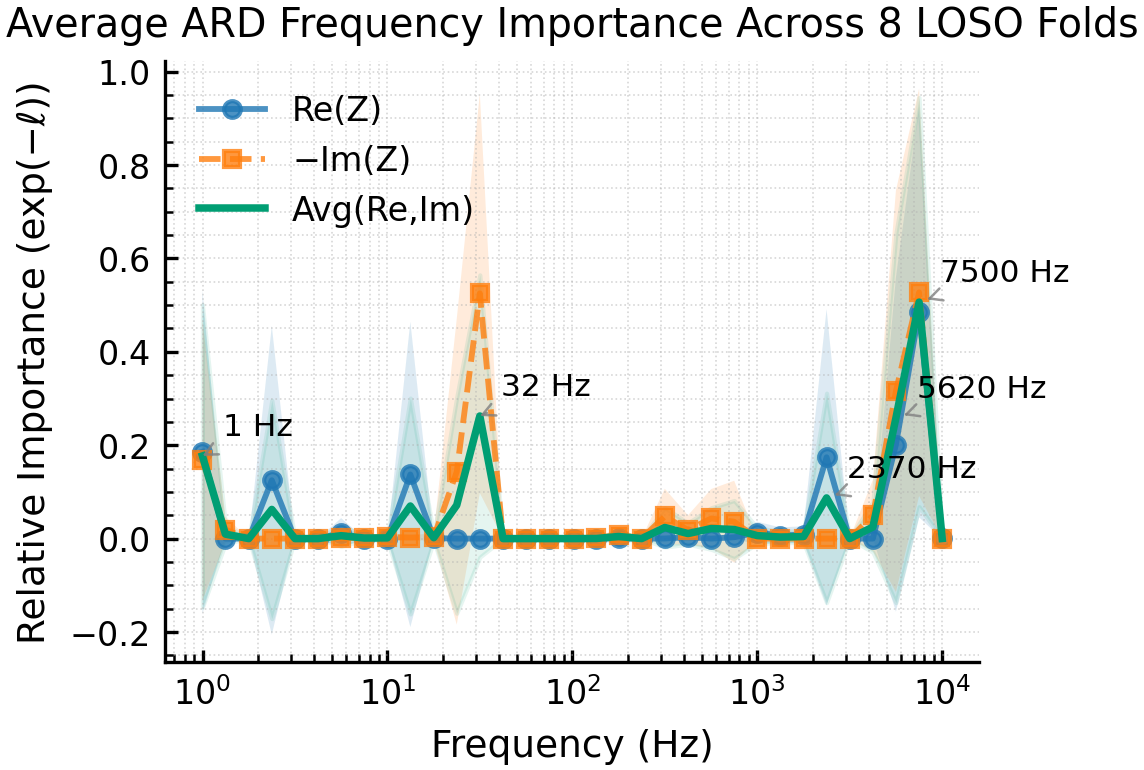

✅ Saved figure to: ../results/gpr/ard_weights_topK_paperstyle.png

Top frequencies (Hz):
     freq_hz  w_avg_mean
31  7500.000    0.506483
12    31.600    0.262596
30  5620.000    0.258397
0      0.999    0.177048
27  2370.000    0.087101


In [13]:
# === plot_ard_weights_paper_style.py ===
import os
import pandas as pd
import matplotlib.pyplot as plt

# Apply the custom mplstyle for paper-quality plots
plt.style.use(os.path.join("../scripts", "paper.mplstyle"))

# Load ARD CSV
df = pd.read_csv("../results/gpr/ard_weights_across_folds.csv")

# Select top-K most relevant frequencies
K = 5
topk = df.nlargest(K, "w_avg_mean")[["freq_hz", "w_avg_mean"]]

# Plot setup
fig, ax = plt.subplots()

ax.semilogx(df.freq_hz, df.w_re_mean, 'o-', label='Re(Z)', alpha=0.8)
ax.fill_between(df.freq_hz, df.w_re_mean - df.w_re_std, df.w_re_mean + df.w_re_std, alpha=0.15)

ax.semilogx(df.freq_hz, df.w_im_mean, 's--', label='−Im(Z)', alpha=0.8)
ax.fill_between(df.freq_hz, df.w_im_mean - df.w_im_std, df.w_im_mean + df.w_im_std, alpha=0.15)

ax.semilogx(df.freq_hz, df.w_avg_mean, '-', linewidth=1.8, color='#009E73', label='Avg(Re,Im)')
ax.fill_between(df.freq_hz, df.w_avg_mean - df.w_avg_std, df.w_avg_mean + df.w_avg_std, 
                color='#009E73', alpha=0.1)

# Annotate top frequencies directly on the curve
for _, row in topk.iterrows():
    ax.annotate(f"{row.freq_hz:.0f} Hz",
                xy=(row.freq_hz, row.w_avg_mean),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7.5,
                arrowprops=dict(arrowstyle="->", lw=0.6, color='gray', alpha=0.8))

# Labels and formatting
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Relative Importance (exp(−ℓ))")
ax.set_title("Average ARD Frequency Importance Across 8 LOSO Folds")
ax.legend(loc="best")
ax.grid(True, which='both', linestyle=':', linewidth=0.4, alpha=0.5)

# Save high-res figure
save_dir = "../results/gpr"
os.makedirs(save_dir, exist_ok=True)
out_path = os.path.join(save_dir, "ard_weights_topK_paperstyle.png")
plt.savefig(out_path)
plt.show()

print("✅ Saved figure to:", out_path)
print("\nTop frequencies (Hz):")
print(topk)


# Cross fold LOSO with highest frequencies

In [14]:
CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']
results = []
freqs = [0.999,31.600,2370.000,5620.000,7500.000]

for test_cell in CHANNELS:
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])

    X_train, y_train = build_model_input(df_train, freqs=freqs)
    X_test,  y_test  = build_model_input(df_test, freqs=freqs)

    model = gpr.train_capacity_gpr_fast(X_train, y_train, subset_size=500)
    y_pred, y_std = gpr.predict_fast(model, X_test)

    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    results.append((test_cell, rmse, mae, r2))


In [15]:
results

[('A1',
  np.float64(0.02098367162479611),
  0.01640069912943341,
  0.9616765785916146),
 ('A2',
  np.float64(0.05746422898921312),
  0.05322163773651551,
  0.80615060644627),
 ('A3',
  np.float64(0.05490136826257899),
  0.04413749456942049,
  0.6017835430899985),
 ('A4',
  np.float64(0.13299355209853256),
  0.07405924752354975,
  0.5515610729952587),
 ('A5',
  np.float64(0.09884285382901012),
  0.07520090123610065,
  0.9323365585352162),
 ('A6',
  np.float64(0.008311414136391434),
  0.007821087330274435,
  0.9098321134258334),
 ('A7',
  np.float64(0.11615260467133498),
  0.08093165703162354,
  0.9029855420520689),
 ('A8',
  np.float64(0.028084613857891797),
  0.02678391643543251,
  0.7857678213426564)]

In [16]:
import os, json

df = pd.DataFrame(results, columns=["cell", "rmse", "mae", "r2"]).sort_values("cell")

summary = pd.DataFrame({
    "cell": ["_mean_"],
    "rmse": [df["rmse"].mean()],
    "mae":  [df["mae"].mean()],
    "r2":   [df["r2"].mean()],
})
df_out = pd.concat([df, summary], ignore_index=True)

save_dir = os.path.join("../results", "gpr")
os.makedirs(save_dir, exist_ok=True)

csv_path  = os.path.join(save_dir, "gpr-select-freqs_8_fold_cv_results.csv")
json_path = os.path.join(save_dir, "gpr-select-freqs_8_fold_cv_results.json")

df_out.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(df.to_dict(orient="records"), f, indent=2)

print(f"Results saved to:\n  • {csv_path}\n  • {json_path}")
print("\n Fold-wise summary:\n", df_out)


Results saved to:
  • ../results/gpr/gpr-select-freqs_8_fold_cv_results.csv
  • ../results/gpr/gpr-select-freqs_8_fold_cv_results.json

 Fold-wise summary:
      cell      rmse       mae        r2
0      A1  0.020984  0.016401  0.961677
1      A2  0.057464  0.053222  0.806151
2      A3  0.054901  0.044137  0.601784
3      A4  0.132994  0.074059  0.551561
4      A5  0.098843  0.075201  0.932337
5      A6  0.008311  0.007821  0.909832
6      A7  0.116153  0.080932  0.902986
7      A8  0.028085  0.026784  0.785768
8  _mean_  0.064717  0.047320  0.806512


Bad value in file '../scripts/paper.mplstyle', line 41 ("axes.prop_cycle: cycler(color=['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000'])"): Key axes.prop_cycle: "cycler(color=['" is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


Saved figure to ../results/gpr/gpr_8fold_r2_comparison.png


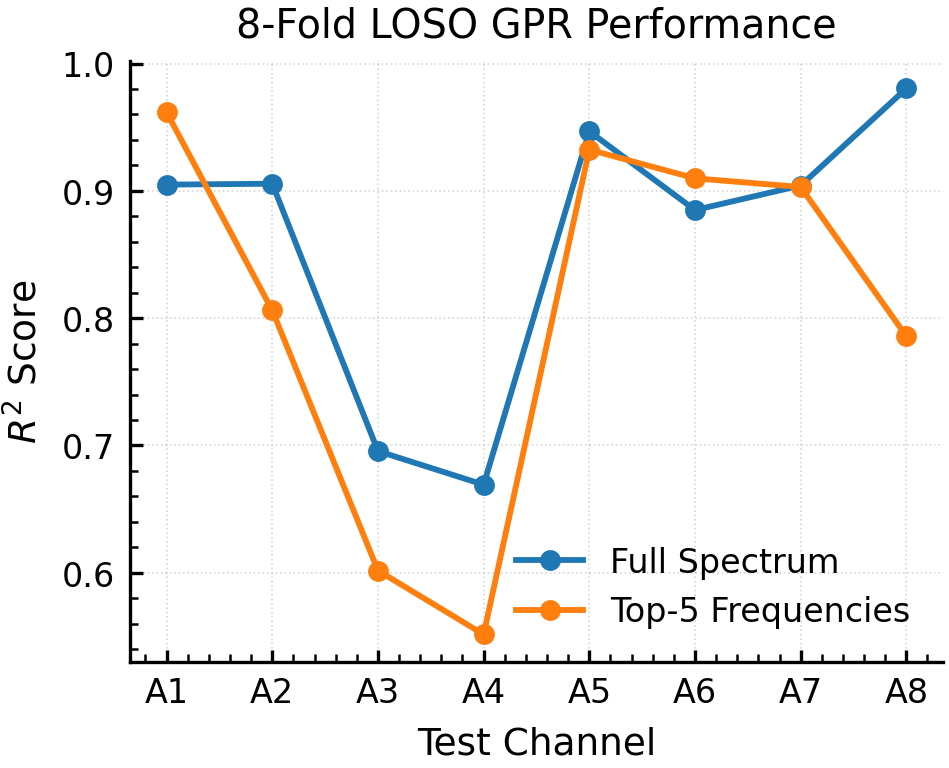

In [18]:
from pathlib import Path

# === Paths ===
results_dir = Path("../results/gpr")
full_file = results_dir / "gpr_8_fold_cv_results.csv"
top_file  = results_dir / "gpr-select-freqs_8_fold_cv_results.csv"

# === Load
df_full = pd.read_csv(full_file)
df_top  = pd.read_csv(top_file)

# Normalize column name: use 'channel'
name_col = "channel" if "channel" in df_full.columns else "cell"
df_full = df_full.rename(columns={name_col: "channel"})
name_col = "channel" if "channel" in df_top.columns else "cell"
df_top  = df_top.rename(columns={name_col: "channel"})

# Drop optional summary row (e.g., "_mean_") if present
df_full = df_full[df_full["channel"].astype(str) != "_mean_"].copy()
df_top  = df_top[df_top["channel"].astype(str)  != "_mean_"].copy()

# Tag model type
df_full["model"] = "Full Spectrum"
df_top["model"]  = "Top-5 Frequencies"

# Combine + sort channels
df = pd.concat([df_full, df_top], ignore_index=True)
order = ["A1","A2","A3","A4","A5","A6","A7","A8"]
df["channel"] = pd.Categorical(df["channel"], categories=order, ordered=True)
df = df.sort_values("channel")

# Apply paper style
plt.style.use("../scripts/paper.mplstyle")

# --- R² comparison plot ---
fig, ax = plt.subplots()
for model, sub in df.groupby("model"):
    ax.plot(sub["channel"], sub["r2"], marker="o", label=model)

ax.set_xlabel("Test Channel")
ax.set_ylabel(r"$R^2$ Score")
ax.set_title("8-Fold LOSO GPR Performance")
ax.legend()

out_path = results_dir / "gpr_8fold_r2_comparison.png"
fig.savefig(out_path)
print(f"Saved figure to {out_path}")

plt.show()
